# Week 1 Mini Project: Sales Data Analysis
**Prepared by:** Jagadish Pothuraju  
**Domain:** Artificial Intelligence and Machine Learning

## Objective
Load a CSV, clean missing data, analyze sales, create four visualizations, and summarize 5–8 insights.

**Dataset note:** The included CSV is synthetic practice data so the project runs offline. If your internship requires a real externally sourced dataset, replace it with a real CSV and cite its source in the README.


In [1]:
%pip install pandas numpy matplotlib seaborn


Note: you may need to restart the kernel to use updated packages.


In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
DATA_PATH = Path("../data/sales_data.csv")
if not DATA_PATH.exists():
    DATA_PATH = Path("data/sales_data.csv")
df = pd.read_csv(DATA_PATH)
print("Dataset shape:", df.shape)
display(df.head())


Dataset shape: (48, 7)


,Date,Region,Category,Product,Units_Sold,Unit_Price,Unit_Cost
0,2025-01-05,North,Electronics,Laptop,2.0,750.0,120.0
1,2025-01-08,South,Furniture,Chair,8.0,55.0,12.0
2,2025-01-12,East,Office Supplies,Notebook,40.0,3.0,0.8
3,2025-01-19,West,Electronics,Headphones,12.0,35.0,8.0
4,2025-02-03,North,Furniture,Desk,3.0,180.0,35.0


## 1. Explore and clean the data

In [3]:
df.info()
display(df.describe(include="all").T)
print("Missing values before cleaning:")
display(df.isna().sum().to_frame("Missing values"))

df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df["Region"] = df["Region"].fillna("Unknown")
for col in ["Units_Sold", "Unit_Cost", "Unit_Price"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")
    df[col] = df[col].fillna(df[col].median())
df = df.dropna(subset=["Date", "Category"]).copy()
df["Revenue"] = df["Units_Sold"] * df["Unit_Price"]
df["Cost"] = df["Units_Sold"] * df["Unit_Cost"]
df["Profit"] = df["Revenue"] - df["Cost"]
print("Missing values after cleaning:")
display(df.isna().sum().to_frame("Missing values"))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Date        48 non-null     object 
 1   Region      47 non-null     object 
 2   Category    48 non-null     object 
 3   Product     48 non-null     object 
 4   Units_Sold  47 non-null     float64
 5   Unit_Price  48 non-null     float64
 6   Unit_Cost   47 non-null     float64
dtypes: float64(3), object(4)
memory usage: 2.8+ KB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Date,48,48,2025-01-05,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Region,47,4,North,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Category,48,3,Electronics,17,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product,48,7,Chair,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Units_Sold,47.0,NaN,NaN,NaN,41.765957,55.374304,1.0,4.5,11.0,77.5,190.0
Unit_Price,48.0,NaN,NaN,NaN,174.78125,251.856319,1.5,3.0,55.0,187.5,750.0
Unit_Cost,47.0,NaN,NaN,NaN,30.904255,40.39084,0.3,0.8,12.0,37.5,120.0


Missing values before cleaning:


,Missing values
Date,0
Region,1
Category,0
Product,0
Units_Sold,1
Unit_Price,0
Unit_Cost,1


Missing values after cleaning:


,Missing values
Date,0
Region,0
Category,0
Product,0
Units_Sold,0
Unit_Price,0
Unit_Cost,0
Revenue,0
Cost,0
Profit,0


## 2. Basic analysis

In [4]:
print(f"Total revenue: {df['Revenue'].sum():,.2f}")
print(f"Estimated total profit: {df['Profit'].sum():,.2f}")
print(f"Units sold: {df['Units_Sold'].sum():,.0f}")
df["Month"] = df["Date"].dt.to_period("M").astype(str)
monthly = df.groupby("Month", as_index=False)[["Revenue", "Profit"]].sum()
category_summary = df.groupby("Category", as_index=False)[["Revenue", "Profit", "Units_Sold"]].sum().sort_values("Revenue", ascending=False)
region_summary = df.groupby("Region", as_index=False)[["Revenue", "Profit"]].sum().sort_values("Profit", ascending=False)
display(monthly)
display(category_summary)
display(region_summary)


Total revenue: 38,812.50
Estimated total profit: 31,369.00
Units sold: 1,974


,Month,Revenue,Profit
0,2025-01,2480.0,2016.0
1,2025-02,1770.0,1443.0
2,2025-03,2115.0,1677.0
3,2025-04,2455.0,1999.0
4,2025-05,3750.0,3017.0
5,2025-06,3660.0,2987.0
6,2025-07,2765.0,2198.0
7,2025-08,3322.5,2711.0
8,2025-09,3610.0,2870.0
9,2025-10,3550.0,2894.0


,Category,Revenue,Profit,Units_Sold
0,Electronics,24895.0,20423.0,149.0
1,Furniture,10325.0,8209.0,115.0
2,Office Supplies,3592.5,2737.0,1710.0


,Region,Revenue,Profit
1,North,13545.0,11152.0
2,South,9300.0,7428.0
0,East,8992.5,7366.0
4,West,6225.0,4793.0
3,Unknown,750.0,630.0


## 3. Visualization 1 — Monthly revenue

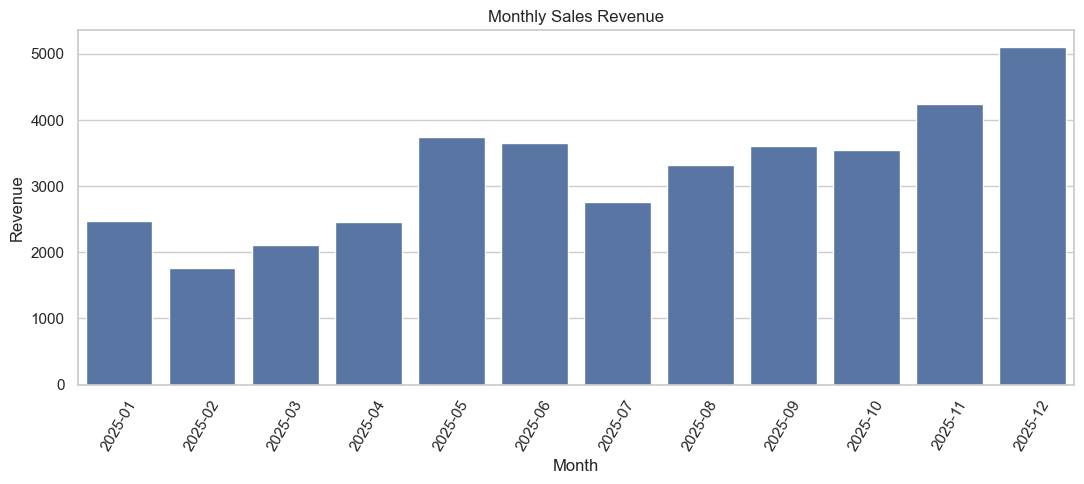

In [5]:
plt.figure(figsize=(11,5))
sns.barplot(data=monthly, x="Month", y="Revenue")
plt.title("Monthly Sales Revenue"); plt.xlabel("Month"); plt.ylabel("Revenue")
plt.xticks(rotation=60); plt.tight_layout(); plt.show()


## 4. Visualization 2 — Revenue by category

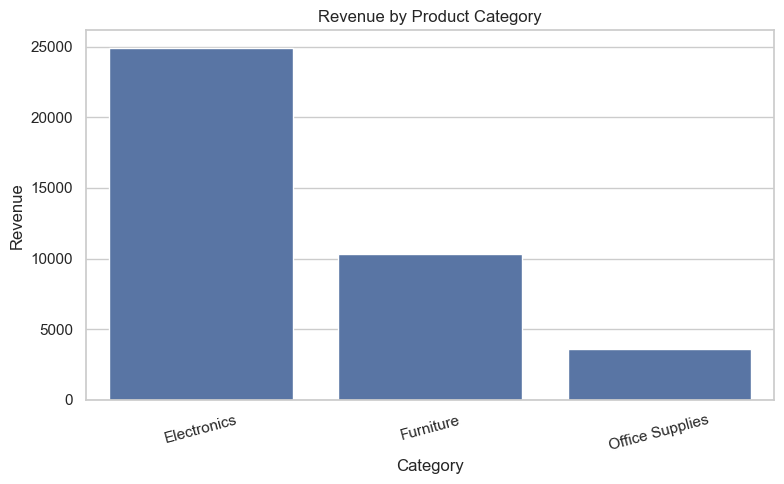

In [6]:
plt.figure(figsize=(8,5))
sns.barplot(data=category_summary, x="Category", y="Revenue")
plt.title("Revenue by Product Category"); plt.xticks(rotation=15)
plt.tight_layout(); plt.show()


## 5. Visualization 3 — Profit by region

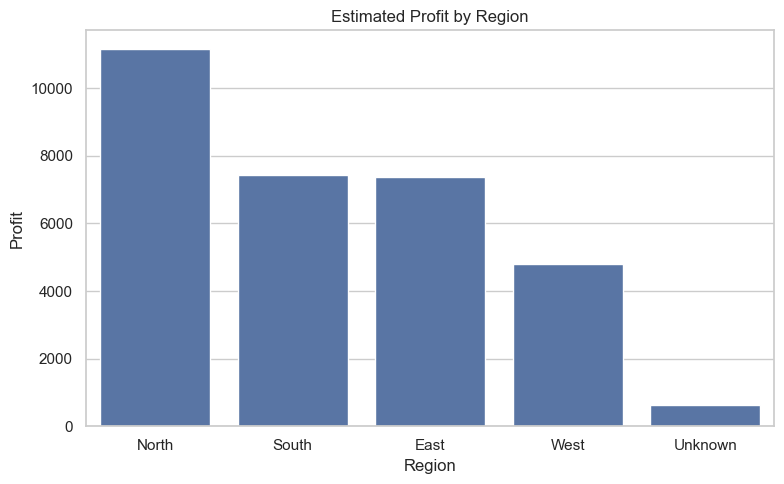

In [7]:
plt.figure(figsize=(8,5))
sns.barplot(data=region_summary, x="Region", y="Profit")
plt.title("Estimated Profit by Region"); plt.tight_layout(); plt.show()


## 6. Visualization 4 — Profit distribution

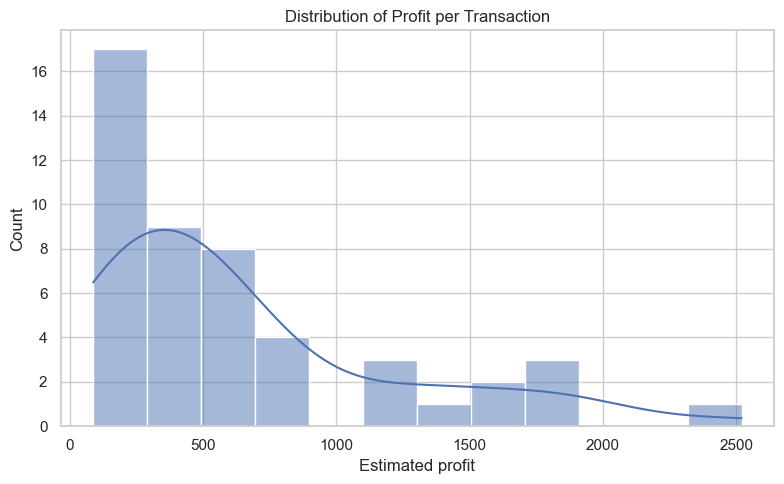

In [8]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x="Profit", bins=12, kde=True)
plt.title("Distribution of Profit per Transaction")
plt.xlabel("Estimated profit"); plt.tight_layout(); plt.show()


## 7. Key insights (generated from the dataset)

In [10]:
best_category = category_summary.iloc[0]
best_region = region_summary.iloc[0]
best_month = monthly.loc[monthly["Revenue"].idxmax()]
lowest_month = monthly.loc[monthly["Revenue"].idxmin()]
insights = [
    f"Total revenue was {df['Revenue'].sum():,.2f}.",
    f"Estimated total profit was {df['Profit'].sum():,.2f}.",
    f"{best_category['Category']} generated the highest category revenue ({best_category['Revenue']:,.2f}).",
    f"{best_region['Region']} had the highest estimated regional profit ({best_region['Profit']:,.2f}).",
    f"{best_month['Month']} was the highest-revenue month ({best_month['Revenue']:,.2f}).",
    f"{lowest_month['Month']} was the lowest-revenue month ({lowest_month['Revenue']:,.2f}).",
    "The histogram reveals the spread of transaction profit and helps identify common ranges."
]
for i, item in enumerate(insights, 1):
    print(f"{i}. {item}")


1. Total revenue was 38,812.50.
2. Estimated total profit was 31,369.00.
3. Electronics generated the highest category revenue (24,895.00).
4. North had the highest estimated regional profit (11,152.00).
5. 2025-12 was the highest-revenue month (5,100.00).
6. 2025-02 was the lowest-revenue month (1,770.00).
7. The histogram reveals the spread of transaction profit and helps identify common ranges.


## 8. Conclusion
This project applies basic Python data analysis skills by loading a CSV, cleaning missing values, calculating revenue/cost/profit, summarizing performance, and creating four visualizations. The charts make trends and comparisons easier to understand.

**Reminder:** The bundled dataset is synthetic. Replace it with a real CSV if required by your assignment and regenerate the insights before submission.
